<a href="https://colab.research.google.com/github/uldopp/TMON/blob/main/PROJECT/PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import OrdinalEncoder

In [146]:
# Функции, которая вычисляет все нужные метрики

def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)

    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()




    print(f'RMSE:  {round(RMSE,4)}\n  R2: {round(R2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(cv_score.mean(),4)}')
    return R2, adjusted_r2, CV_R2, RMSE

In [8]:
df = pd.read_excel('StressLevelDataset.xlsx')

In [59]:
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,14,20,0,11,2,1,2,4,2,3,...,2,3,2,3,3,2,3,3,2,1
1,15,8,1,15,5,3,1,4,3,1,...,2,1,4,1,5,1,4,5,5,2
2,12,18,1,14,2,1,2,2,2,2,...,2,2,3,3,2,2,3,2,2,1
3,16,12,1,15,4,3,1,3,4,2,...,2,2,4,1,4,1,4,4,5,2
4,16,28,0,7,2,3,5,1,3,2,...,3,4,3,1,2,1,5,0,5,1


Набор данных содержит около 20 функций, которые оказывают наибольшее влияние на стресс студента. Характеристики отбираются научно с учётом пяти основных факторов: психологический, физиологический, социальный, экологический и академический.
1.   Психологические факторы:
*   anxiety_level - уровень тревожности
*   self_esteem - самооценка
*   mental_health_history - наличие проблем с психическим здоровьем
*   depression - уровень депрессии
2.   Физические факторы:
*   headache - головные боли
*   blood_pressure - артериальное давление
*   sleep_quality - качество сна
*   breathing_problem - проблемы с дыханием
3.   Социальные факторы:
*   noise_level - уровень шума
*   living_conditions - условия проживания
*   safety - ощущение безопасности
*   basic_needs - удовлетворение базовым потребностей
*   social_support - социальная поддержка
*   peer_pressure - давление со стороны сверстников
*   bullyng - буллинг
4.   Академические факторы:
*   academic_performance - академическая успеваемость
*   study_load - учебная нагрузка
*   teacher_student_relationship - отношение между преподавателями и студентами
*   future_career_concerns - беспокойство о будущей карьере
*   extracurricular_activities - внеучебная активность
5.   Результат:
*   stress_level - уровень стресса






In [60]:
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер датасета: 1100 строк, 21 столбцов


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   anxiety_level                 1100 non-null   int64
 1   self_esteem                   1100 non-null   int64
 2   mental_health_history         1100 non-null   int64
 3   depression                    1100 non-null   int64
 4   headache                      1100 non-null   int64
 5   blood_pressure                1100 non-null   int64
 6   sleep_quality                 1100 non-null   int64
 7   breathing_problem             1100 non-null   int64
 8   noise_level                   1100 non-null   int64
 9   living_conditions             1100 non-null   int64
 10  safety                        1100 non-null   int64
 11  basic_needs                   1100 non-null   int64
 12  academic_performance          1100 non-null   int64
 13  study_load                    110

В данном датаесете нет пропусков, все столбцы имеют тип int64, что говорит об отсутствии категориальных, текстовых, вещественных признаков.

In [62]:
df.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,...,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,11.063636,17.777273,0.492727,12.555455,2.508182,2.181818,2.660000,2.753636,2.649091,2.518182,...,2.772727,2.772727,2.621818,2.648182,2.649091,1.881818,2.734545,2.767273,2.617273,0.996364
std,6.117558,8.944599,0.500175,7.727008,1.409356,0.833575,1.548383,1.400713,1.328127,1.119208,...,1.433761,1.414594,1.315781,1.384579,1.529375,1.047826,1.425265,1.417562,1.530958,0.821673
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,0.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,0.000000
50%,11.000000,19.000000,0.000000,12.000000,3.000000,2.000000,2.500000,3.000000,3.000000,2.000000,...,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.500000,3.000000,1.000000
75%,16.000000,26.000000,1.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,...,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,2.000000
max,21.000000,30.000000,1.000000,27.000000,5.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000,2.000000


Можно заметить что признаки имеют разные шкалы. Это означает, что для использования линейных моделей  или методов, основанных на расстояниях, необходимо масштабирование.

In [63]:
print(f"\nПропущенные значения:\n{df.isnull().sum()}")


Пропущенные значения:
anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64


Датасет не имеет пропущенных значений.


Распределение целевой переменной stress_level

In [64]:
# Распределение stress_level
print(f"\nРаспределение stress_level:\n{df['stress_level'].value_counts()}")
print(f"\nПроцентное распределение:\n{df['stress_level'].value_counts(normalize=True) * 100}")




Распределение stress_level:
stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Процентное распределение:
stress_level
0    33.909091
2    33.545455
1    32.545455
Name: proportion, dtype: float64


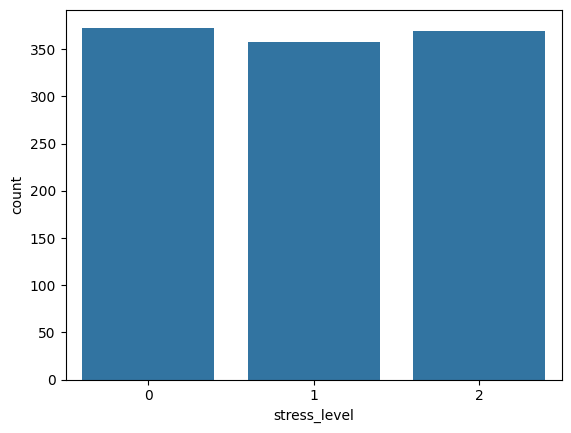

In [65]:
sns.countplot(x=df['stress_level']);

Сбалансированное распределение классов.

Визуализация распределения всех числовых признаков с помощью гистограмм.

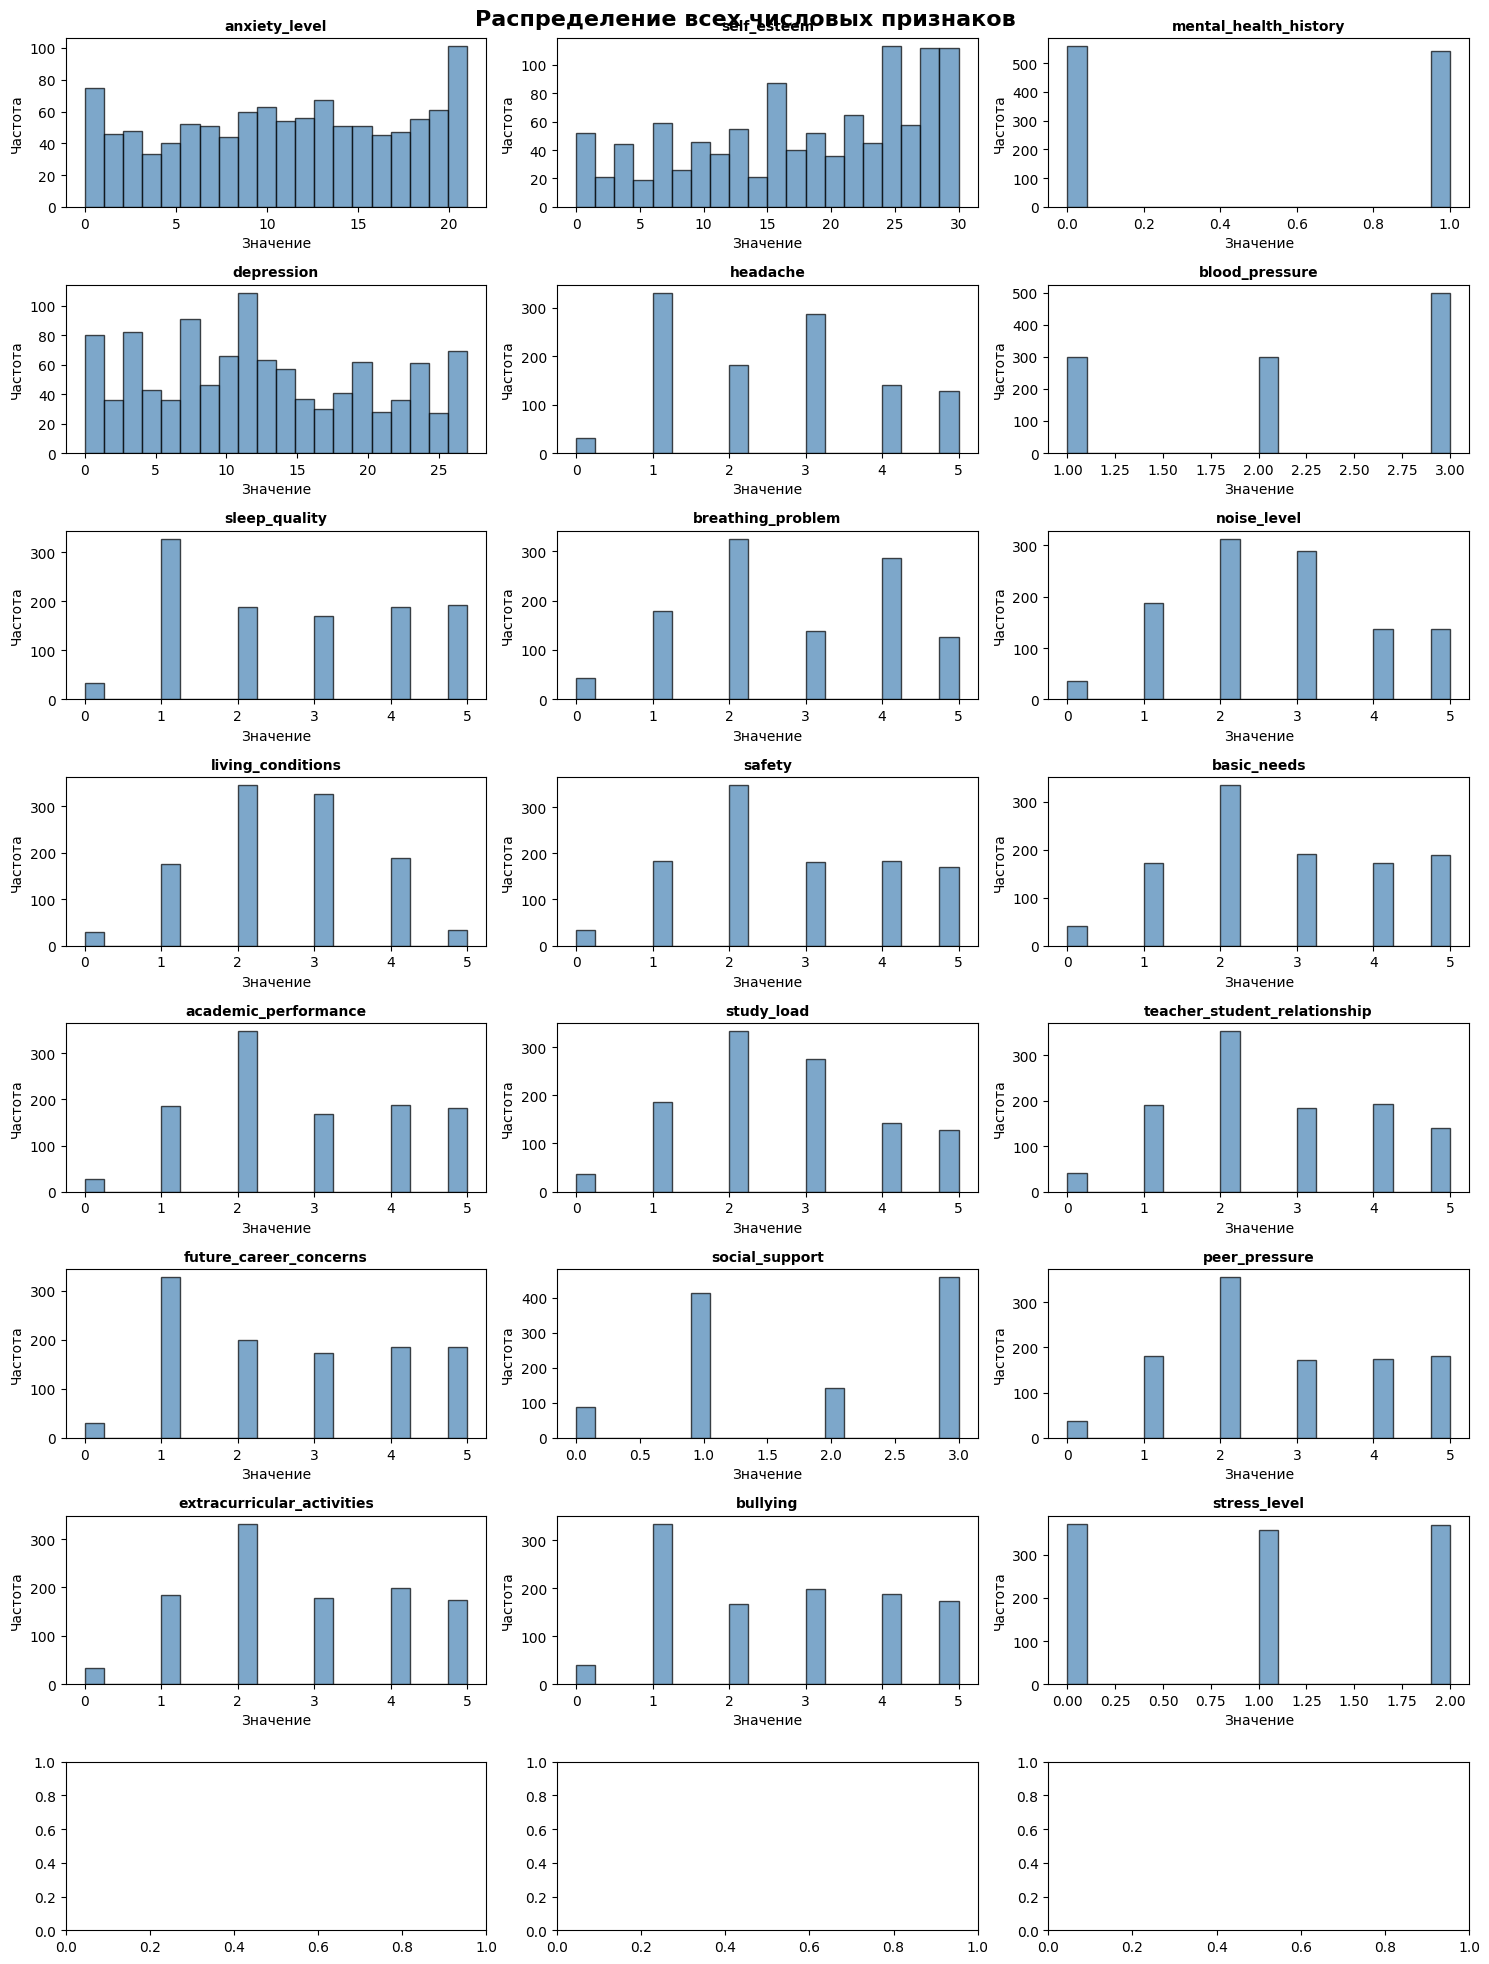

In [66]:
# Разделяем признаки на категории
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Гистограммы для числовых признаков
fig, axes = plt.subplots(8, 3, figsize=(15, 20))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    axes[idx].hist(df[feature], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(feature, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')

plt.suptitle('Распределение всех числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('features_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Корреляция — это статистическая мера, которая показывает силу и направление связи между двумя переменными.

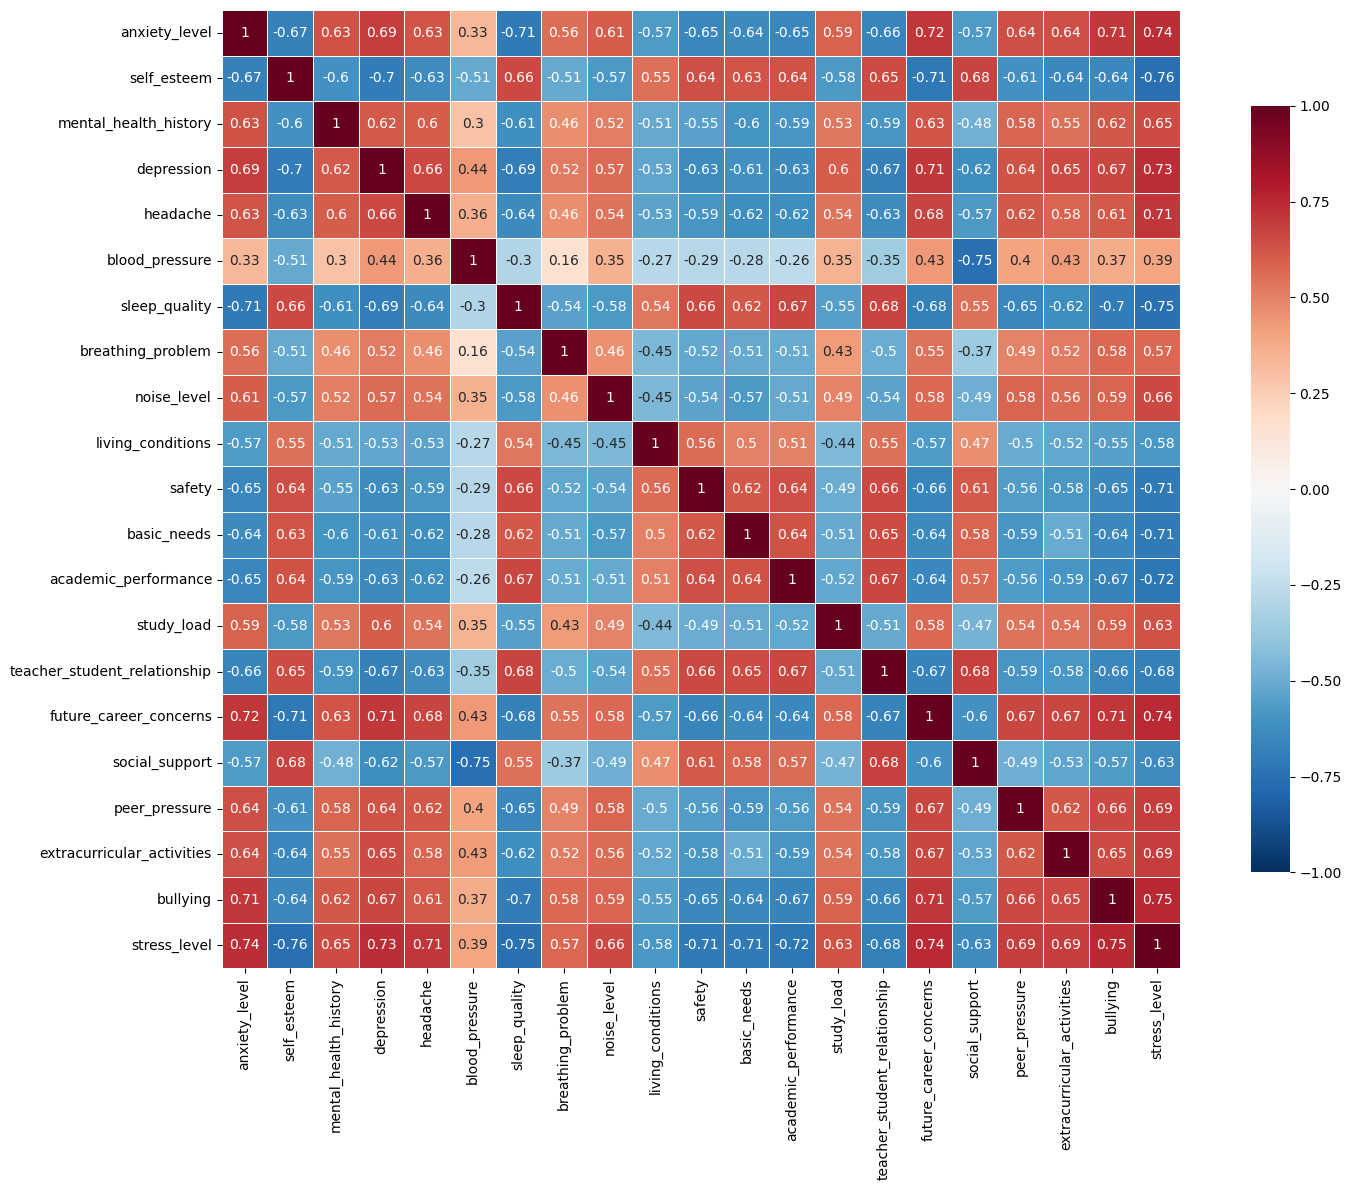

In [67]:
# Вычисляем корреляцию с target
correlations = df.corr()['stress_level'].sort_values(ascending=False)

# ПОЛНАЯ тепловая карта корреляций (без маски)
plt.figure(figsize=(16, 12))

# Полная матрица корреляций (без маски)
sns.heatmap(df.corr(),
            annot=True,           # можно изменить на True, чтобы видеть значения
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)       # фиксированный диапазон для корреляций
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png', dpi=300, bbox_inches='tight')
plt.show()

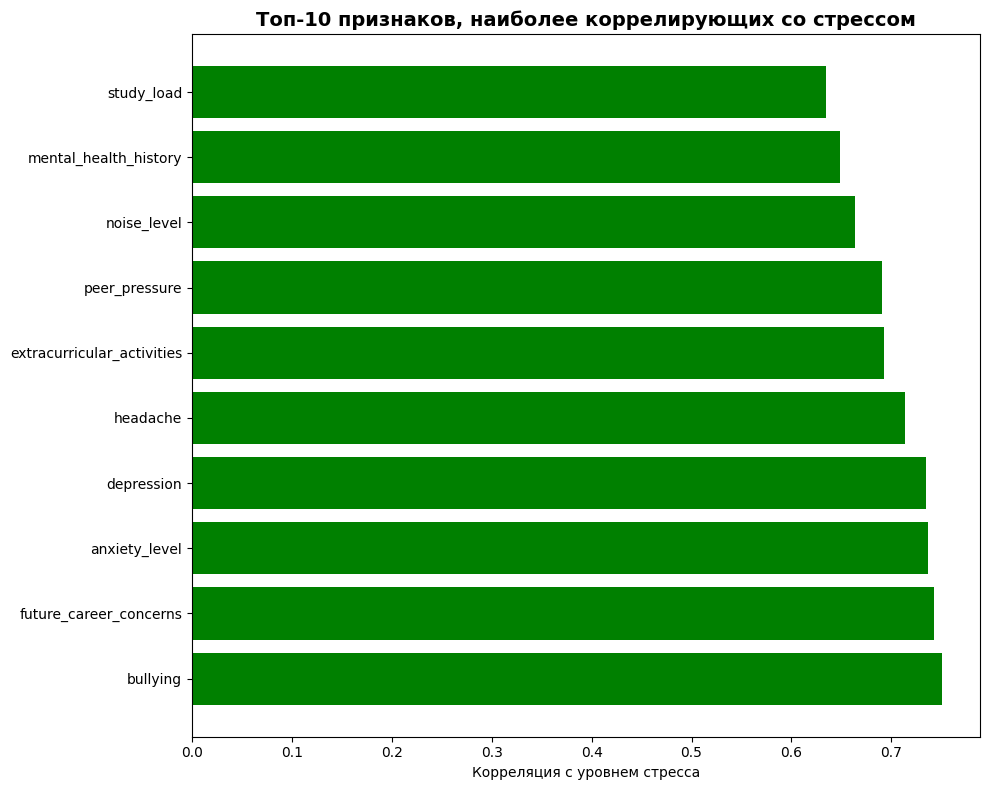

In [68]:
# Топ-10 признаков, наиболее коррелирующих со стрессом
plt.figure(figsize=(10, 8))
top_corr = correlations.drop('stress_level').head(10)
colors_corr = ['red' if x < 0 else 'green' for x in top_corr.values]
plt.barh(range(len(top_corr)), top_corr.values, color=colors_corr)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Корреляция с уровнем стресса')
plt.title('Топ-10 признаков, наиболее коррелирующих со стрессом', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

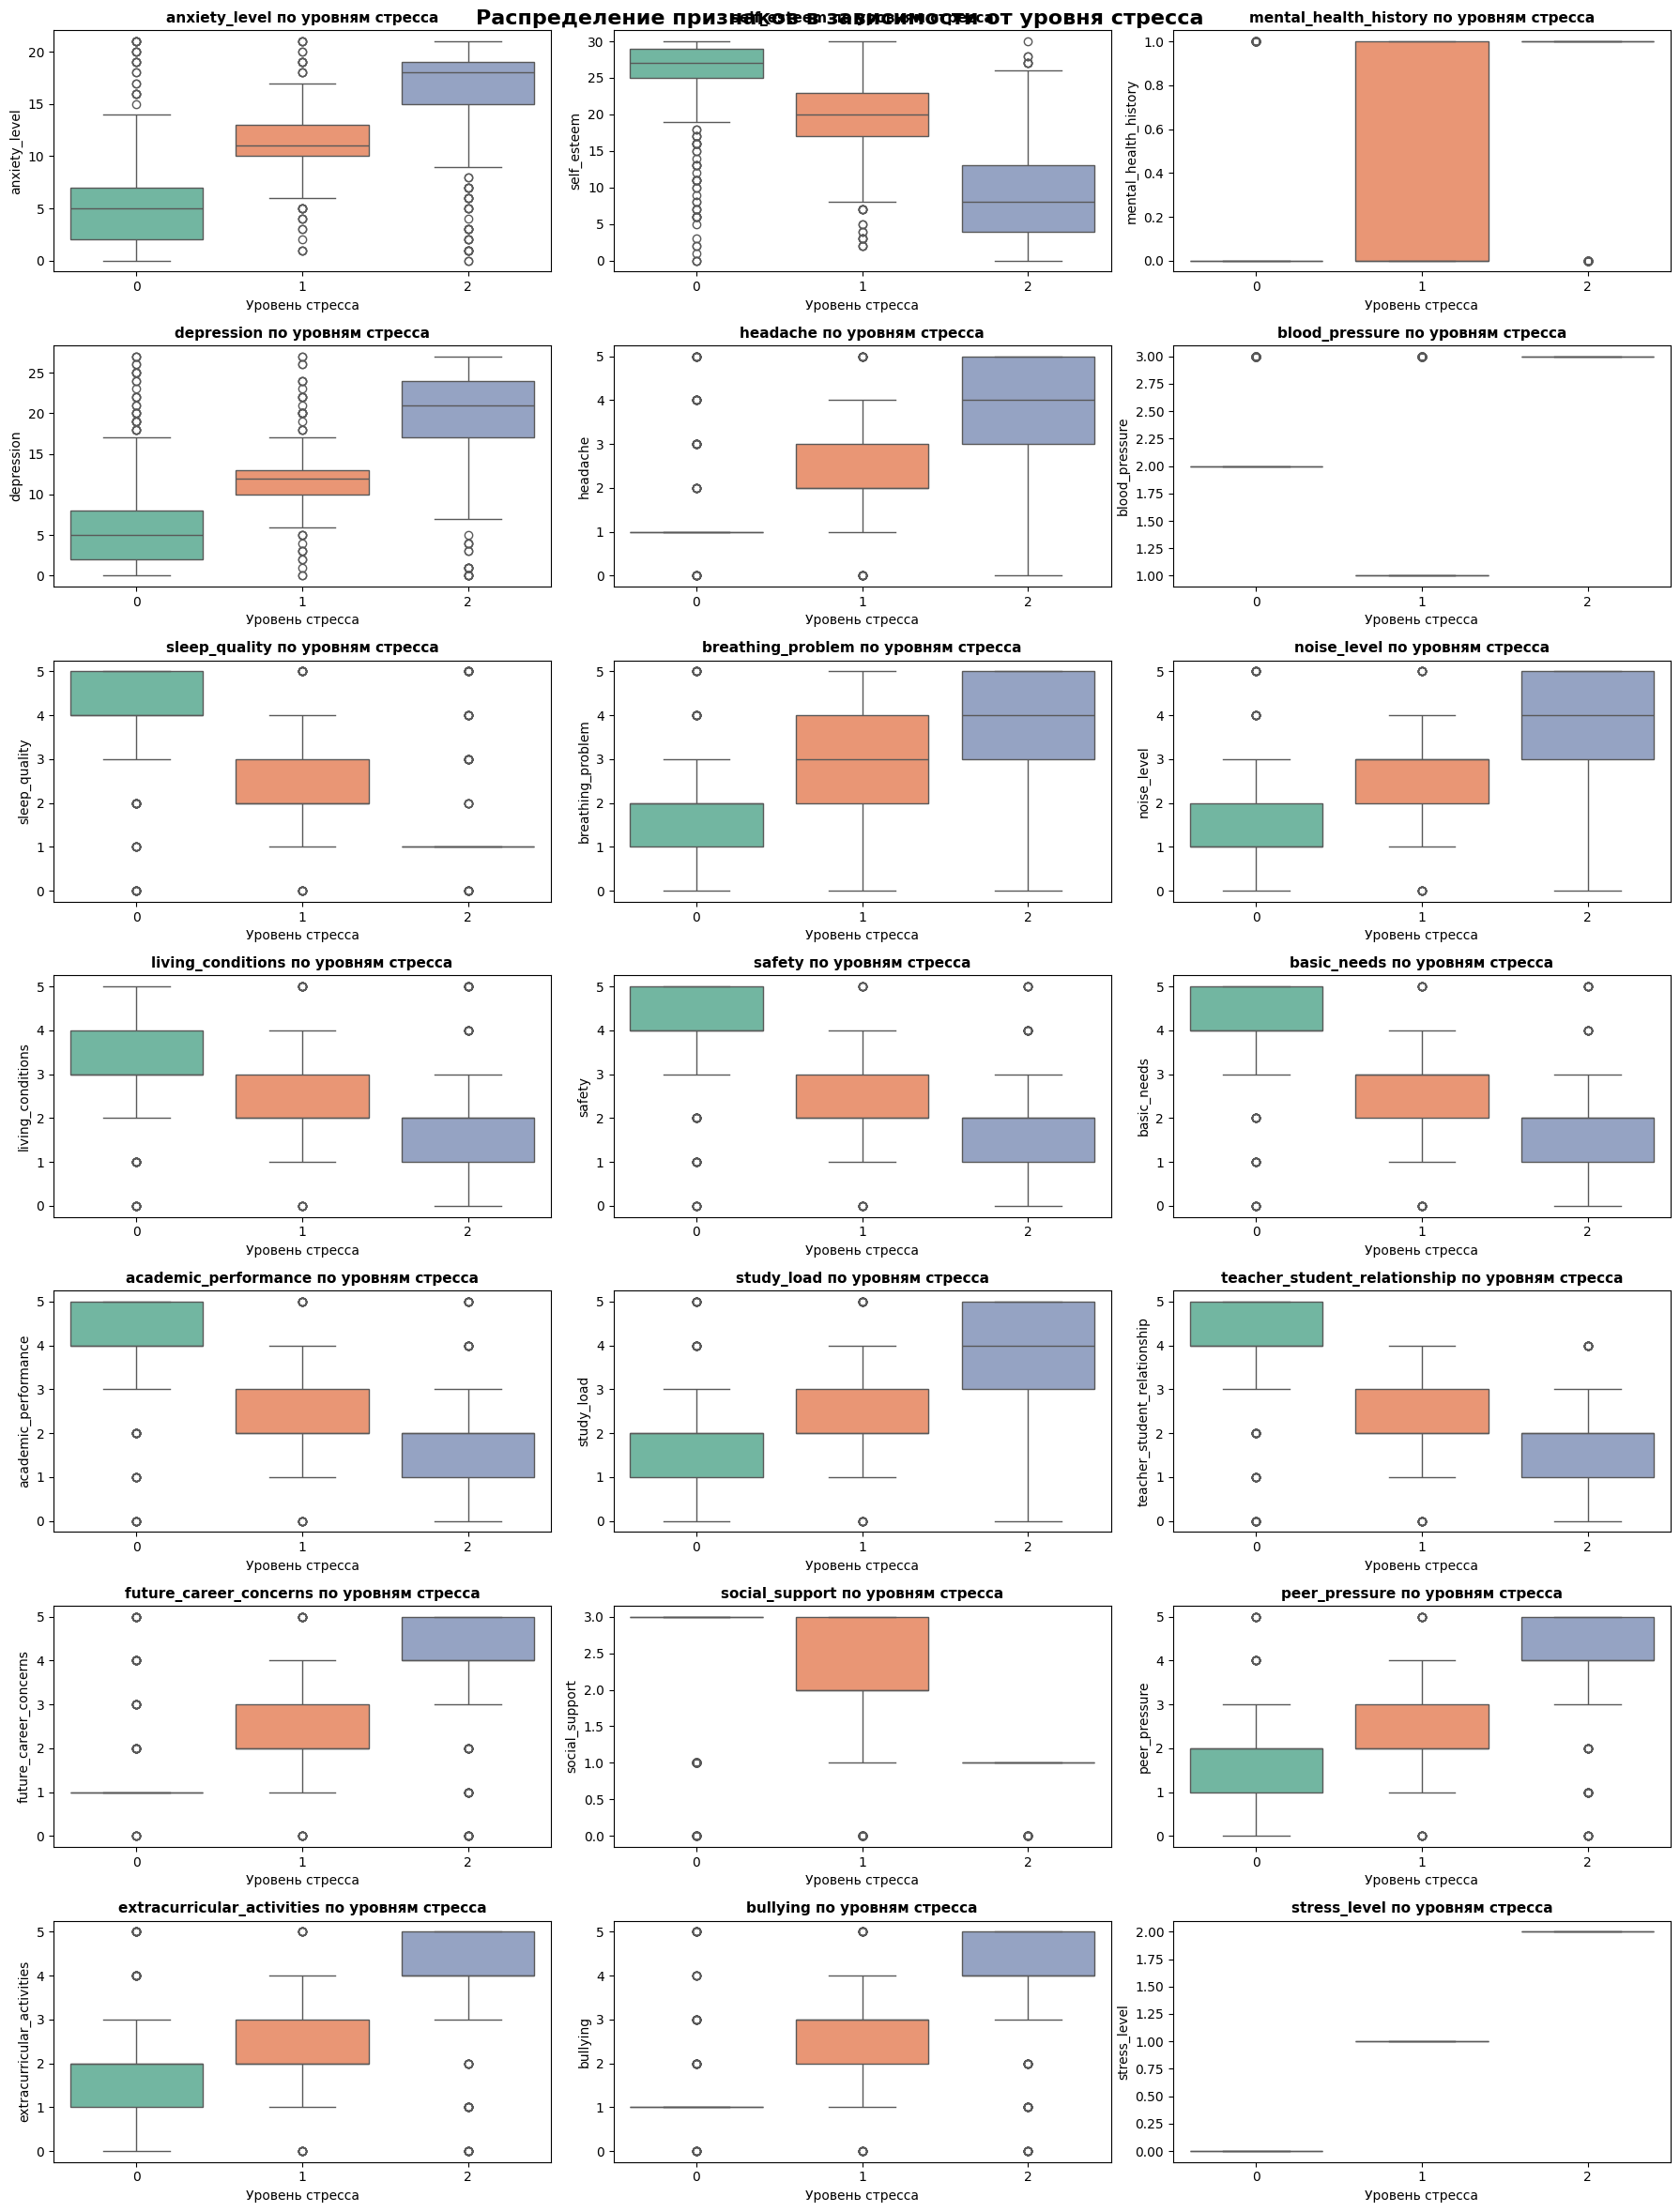

In [69]:
# Boxplot для всех признаков по уровням стресса
fig, axes = plt.subplots(7, 3, figsize=(18, 24))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    sns.boxplot(x='stress_level', y=feature, data=df, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} по уровням стресса', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Уровень стресса')
    axes[idx].set_ylabel(feature)

plt.suptitle('Распределение признаков в зависимости от уровня стресса', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('features_by_stress.png', dpi=300, bbox_inches='tight')
plt.show()


Масштабирование признаков (feature scaling) — это важный этап предобработки данных в машинном обучении. Его основная цель — привести все числовые характеристики к одному порядку величин.

Алгоритмы, основанные на оптимизации (градиентный спуск), работают значительно быстрее и стабильнее после масштабирования.

*   Линейная регрессия

*   Логистическая регрессия

*   Нейронные сети

Если признаки находятся в разных масштабах, функция потерь принимает форму «узкого оврага» (вытянутой эллиптической формы). Градиентному спуску приходится долго «зигзагообразно» двигаться к минимуму. После масштабирования (например, до диапазона [0,1] или среднего 0) ландшафт становится сферическим, и алгоритм сходится за гораздо меньшее количество итераций.

In [148]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Отделяем признаки от целевой переменной
X = df.drop('stress_level', axis=1)
y = df['stress_level']

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Создание датафрейма с масштабированными данными
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled['stress_level'] = y.values

# Сохранение
df_scaled.to_excel('StressLevelDataset_Scaled.xlsx', index=False)

print("Масштабирование завершено!")
print(f"Размер данных: {df_scaled.shape}")

Масштабирование завершено!
Размер данных: (1100, 21)


In [149]:
df1 = pd.read_excel('StressLevelDataset_Scaled.xlsx')

In [150]:
df1.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,0.480208,0.248612,-0.985559,-0.201393,-0.360741,-1.418416,-0.426445,0.890211,-0.488949,0.430695,...,-0.539196,0.160736,-0.472800,0.254213,0.229550,0.112839,0.186334,0.164249,-0.403377,1
1,0.643746,-1.093590,1.014653,0.316508,1.768859,0.981981,-1.072574,0.890211,0.264334,-1.357096,...,-0.539196,-1.253741,1.047901,-1.190927,1.537869,-0.841952,0.888277,1.575763,1.557071,2
2,0.153131,0.024912,1.014653,0.187033,-0.360741,-1.418416,-0.426445,-0.538282,-0.488949,-0.463200,...,-0.539196,-0.546502,0.287551,0.254213,-0.424609,0.112839,0.186334,-0.541508,-0.403377,1
3,0.807284,-0.646189,1.014653,0.316508,1.058992,0.981981,-1.072574,0.175964,1.017616,-0.463200,...,-0.539196,-0.546502,1.047901,-1.190927,0.883709,-0.841952,0.888277,0.870006,1.557071,2
4,0.807284,1.143414,-0.985559,-0.719293,-0.360741,0.981981,1.511942,-1.252529,0.264334,-0.463200,...,0.158587,0.867974,0.287551,-1.190927,-0.424609,-0.841952,1.590220,-1.953023,1.557071,1


In [151]:
df1.describe()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
count,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,...,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1.100000e+03,1100.000000
mean,-1.679465e-16,6.782453e-17,2.325413e-16,9.689219e-17,-9.527732e-17,3.488119e-16,6.782453e-17,1.929769e-16,1.614870e-16,1.162706e-16,...,-2.018587e-16,-2.220446e-16,2.163926e-16,9.850706e-17,1.695613e-16,-1.065814e-16,4.521636e-17,1.356491e-16,4.844610e-18,0.996364
std,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,...,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,1.000455e+00,0.821673
min,-1.809328e+00,-1.988391e+00,-9.855588e-01,-1.625618e+00,-1.780475e+00,-1.418416e+00,-1.718703e+00,-1.966776e+00,-1.995514e+00,-2.250991e+00,...,-1.934764e+00,-1.960979e+00,-1.993501e+00,-1.913497e+00,-1.732927e+00,-1.796742e+00,-1.919495e+00,-1.953023e+00,-1.710343e+00,0.000000
25%,-8.280983e-01,-7.580391e-01,-9.855588e-01,-8.487679e-01,-1.070608e+00,-1.418416e+00,-1.072574e+00,-5.382823e-01,-4.889489e-01,-4.632004e-01,...,-5.391964e-01,-5.465023e-01,-4.727998e-01,-4.683567e-01,-1.078768e+00,-8.419517e-01,-5.156090e-01,-5.415083e-01,-1.056860e+00,0.000000
50%,-1.040698e-02,1.367622e-01,-9.855588e-01,-7.191751e-02,3.491253e-01,-2.182179e-01,-1.033806e-01,1.759644e-01,2.643337e-01,-4.632004e-01,...,1.585872e-01,-5.465023e-01,-4.727998e-01,-4.683567e-01,-4.246087e-01,1.128389e-01,-5.156090e-01,-1.886297e-01,2.501057e-01,1.000000
75%,8.072843e-01,9.197134e-01,1.014653e+00,8.344079e-01,3.491253e-01,9.819805e-01,8.658128e-01,8.902111e-01,2.643337e-01,4.306951e-01,...,8.563708e-01,8.679743e-01,2.875508e-01,9.767832e-01,8.837095e-01,1.067629e+00,8.882770e-01,8.700062e-01,9.035886e-01,2.000000
max,1.624976e+00,1.367114e+00,1.014653e+00,1.870208e+00,1.768859e+00,9.819805e-01,1.511942e+00,1.604458e+00,1.770899e+00,2.218486e+00,...,1.554154e+00,1.575213e+00,1.808252e+00,1.699353e+00,1.537869e+00,1.067629e+00,1.590220e+00,1.575763e+00,1.557071e+00,2.000000


In [152]:
# Распределение stress_level
print(f"\nРаспределение stress_level:\n{df1['stress_level'].value_counts()}")
print(f"\nПроцентное распределение:\n{df1['stress_level'].value_counts(normalize=True) * 100}")



Распределение stress_level:
stress_level
0    373
2    369
1    358
Name: count, dtype: int64

Процентное распределение:
stress_level
0    33.909091
2    33.545455
1    32.545455
Name: proportion, dtype: float64


In [153]:
# подготавливаем датасет к обучению
X = df1.drop(['stress_level'], axis=1)
y = df1['stress_level']
print(f'X shape: {X.shape} | y shape: {y.shape} ')

X shape: (1100, 20) | y shape: (1100,) 


In [154]:

import scipy.stats as stats
# делим датасет на трейн и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
stats.ttest_ind (a=y_train, b=y_test)

TtestResult(statistic=np.float64(-0.07335643066072974), pvalue=np.float64(0.9415358481143774), df=np.float64(1098.0))

In [155]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")


X_train: (880, 20)
X_test: (220, 20)
y_train: (880,)
y_test: (220,)


# Линейная регрессия


In [156]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
modelLR = LinearRegression()

# Fit the model to the data
modelLR.fit(X_train, y_train)

# Predict the response for a new data point
y_pr_LR = modelLR.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelLR, X_train, y_train, X_test, y_test, y_pr_LR)

RMSE:  0.4112
  R2: 0.7487
 Adjusted R2: 0.7234
 Cross Validated R2: 0.7697


# Полиномиальная регрессия

In [157]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)

poly_features = poly.fit_transform(X)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(poly_features, y, test_size=0.2, random_state=42)

In [158]:
# Create a linear regression model
modelPR = LinearRegression()

# Fit the model to the data
modelPR.fit(X_p_train, y_p_train)

# Predict the response for a new data point
y_pr_PR = modelPR.predict(X_p_test)

_ = Reg_Models_Evaluation_Metrics(modelPR, X_p_train, y_p_train, X_p_test, y_p_test, y_pr_PR)

RMSE:  0.3872
  R2: 0.7755
 Adjusted R2: 1.0317
 Cross Validated R2: 0.7632


# Регрессия дерева принятия решений

In [118]:
from sklearn.tree import DecisionTreeRegressor

# Create a stepwise regression model
modelDT = DecisionTreeRegressor()

# Fit the model to the data
modelDT.fit(X_train, y_train)

# Predict the response for a new data point
y_dt_pred = modelDT.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelDT, X_train, y_train, X_test, y_test, y_dt_pred)

RMSE:  0.5222
  R2: 0.5946
 Adjusted R2: 0.5539
 Cross Validated R2: 0.6609


# Регрессия случайного леса

In [119]:
from sklearn.ensemble import RandomForestRegressor

# Create a stepwise regression model
modelRF = RandomForestRegressor(n_estimators=100)

# Fit the model to the data
modelRF.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelRF.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelRF, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.394
  R2: 0.7692
 Adjusted R2: 0.746
 Cross Validated R2: 0.7957


# Регрессия опорных векторов (SVR)

In [120]:
from sklearn.svm import SVR

# Create a support vector regression model
modelSVR = SVR(kernel='linear')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.4157
  R2: 0.7431
 Adjusted R2: 0.7173
 Cross Validated R2: 0.7766


In [121]:
from sklearn.svm import SVR

# Create a support vector regression model. Полиномиальное ядро
modelSVR = SVR(kernel='poly')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.4508
  R2: 0.698
 Adjusted R2: 0.6676
 Cross Validated R2: 0.7647


In [122]:
# Create a support vector regression model. Ядро - радиальная базисная функция
modelSVR = SVR(kernel='rbf')

modelSVR.fit(X_train, y_train)

# Predict the response for a new data point
y_rf_pred = modelSVR.predict(X_test)


_ = Reg_Models_Evaluation_Metrics(modelSVR, X_train, y_train, X_test, y_test, y_rf_pred)

RMSE:  0.417
  R2: 0.7415
 Adjusted R2: 0.7155
 Cross Validated R2: 0.7702


# Регрессия ElasticNet

In [107]:
from sklearn.linear_model import ElasticNet

# Create an elastic net regression model
modelEN = ElasticNet(alpha=0.1, l1_ratio=0.8)

# Fit the model to the data
modelEN.fit(X_train, y_train)

# Predict the response for a new data point
y_en_pred = modelEN.predict(X_test)

_ = Reg_Models_Evaluation_Metrics(modelEN, X_train, y_train, X_test, y_test, y_en_pred)

RMSE:  0.4147
  R2: 0.7444
 Adjusted R2: 0.7187
 Cross Validated R2: 0.7515


У полиномальной регрессии RMSE оказался меньше, чем у остальных моделей, а R2 больше, чем у сотальных. следовательно, полиномиальная регрессия показала лучший результат.

In [133]:

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
#Обучаем модель Naive Bayes (NB)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

_ = Reg_Models_Evaluation_Metrics(nb_model, X_train, y_train, X_test, y_test, y_pred_nb)

RMSE:  0.5916
  R2: 0.8818
 Adjusted R2: 0.8699
 Cross Validated R2: 0.8773


In [134]:
print(f'NB accuracy: {accuracy_nb}') #общая доля правильных ответов.
print(f'NB prediction: {y_pred_nb}')
print("\nМатрица ошибок (Confusion Matrix):")
print(confusion_matrix(y_test, y_pred_nb))
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_nb, target_names=['(0)', '(1)', '(2)']))

NB accuracy: 0.8818181818181818
NB prediction: [0 0 2 2 2 0 2 2 1 2 1 0 0 2 2 1 1 2 1 1 0 0 0 1 1 0 2 1 0 2 1 1 1 2 0 2 2
 2 2 2 0 2 2 0 0 2 0 1 2 0 1 1 1 1 0 2 2 0 0 0 1 0 0 2 1 1 2 0 2 2 2 1 2 1
 2 1 0 2 0 1 1 2 2 1 0 0 1 1 1 2 2 0 2 1 0 2 2 2 0 1 2 2 0 1 2 1 2 2 0 0 2
 0 2 1 1 2 1 0 2 2 0 2 2 2 0 0 1 1 0 2 0 2 2 1 2 1 1 1 0 1 2 1 1 2 2 1 0 1
 2 0 2 0 0 1 1 2 0 2 1 0 2 0 0 0 1 2 1 1 2 1 0 1 2 2 2 2 0 0 2 1 0 1 1 2 2
 1 1 0 1 1 2 1 0 0 2 0 2 1 2 2 2 2 2 2 0 2 2 0 1 0 2 0 2 2 2 2 0 0 2 0]

Матрица ошибок (Confusion Matrix):
[[60  0 14]
 [ 2 64  6]
 [ 3  1 70]]

Отчет по классификации:
              precision    recall  f1-score   support

         (0)       0.92      0.81      0.86        74
         (1)       0.98      0.89      0.93        72
         (2)       0.78      0.95      0.85        74

    accuracy                           0.88       220
   macro avg       0.90      0.88      0.88       220
weighted avg       0.89      0.88      0.88       220

